In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [24]:
from matplotlib.patches import Patch

In [16]:
data_dir = Path("../data")

In [26]:
pcm_df = pd.read_csv(data_dir / "caiso_wind_solar_pcm.csv")

In [27]:
# Sort the DataFrame by the 2039 curtailment ratio in descending order
pcm_sorted = pcm_df.sort_values(by='Curtailment_Ratio_Pct_2034', ascending=False)

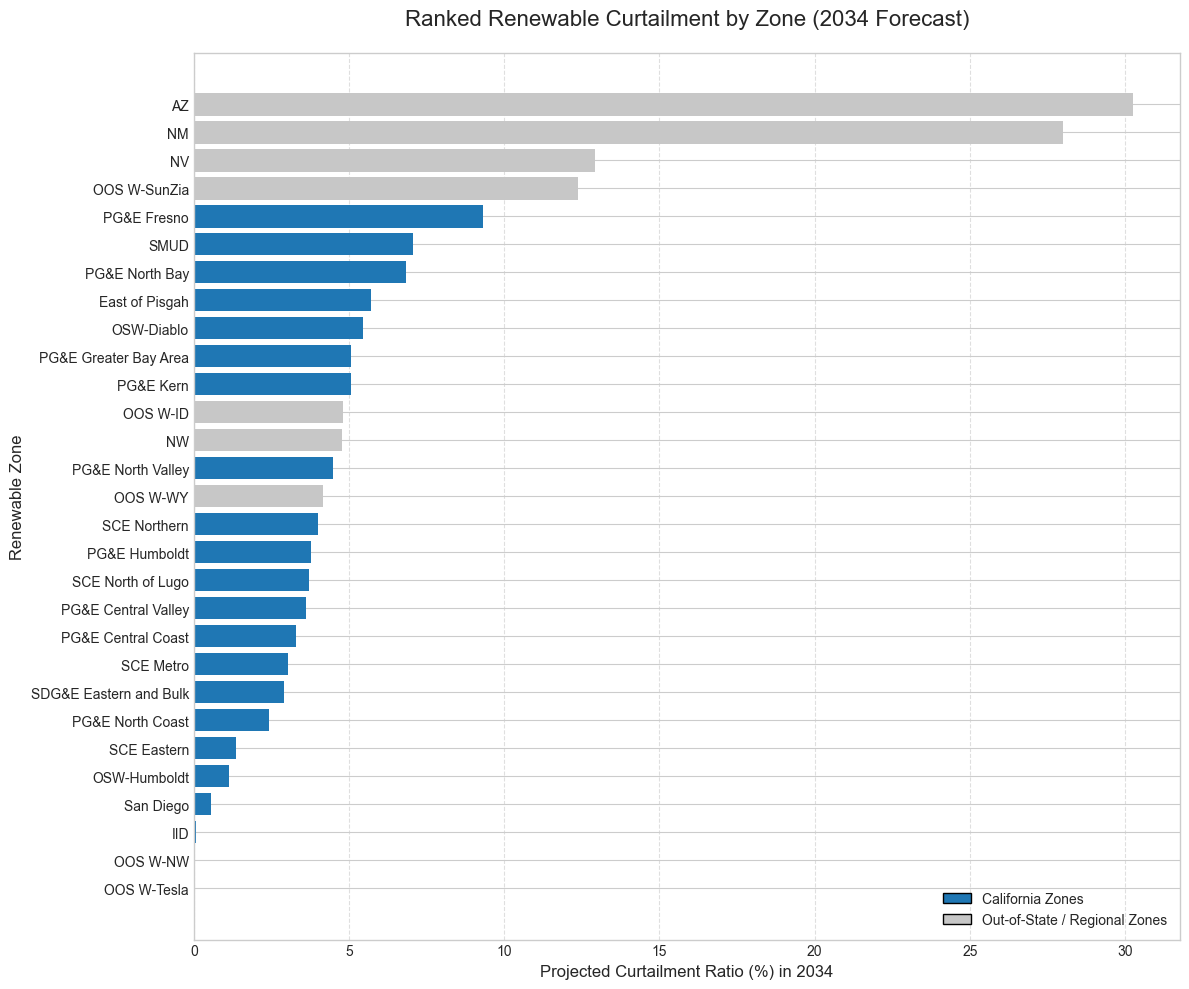

In [28]:
colors = ['#1f77b4' if state == 'CA' else '#c7c7c7' for state in pcm_sorted['State']]
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(pcm_sorted['Renewable_Zone'], pcm_sorted['Curtailment_Ratio_Pct_2034'], color=colors)

ax.invert_yaxis()

ax.set_xlabel('Projected Curtailment Ratio (%) in 2034', fontsize=12)
ax.set_ylabel('Renewable Zone', fontsize=12)
ax.set_title('Ranked Renewable Curtailment by Zone (2034 Forecast)', fontsize=16, pad=20)


legend_elements = [Patch(facecolor='#1f77b4', edgecolor='black', label='California Zones'),
                   Patch(facecolor='#c7c7c7', edgecolor='black', label='Out-of-State / Regional Zones')]
ax.legend(handles=legend_elements, loc='lower right')


ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.tight_layout()

plt.show()

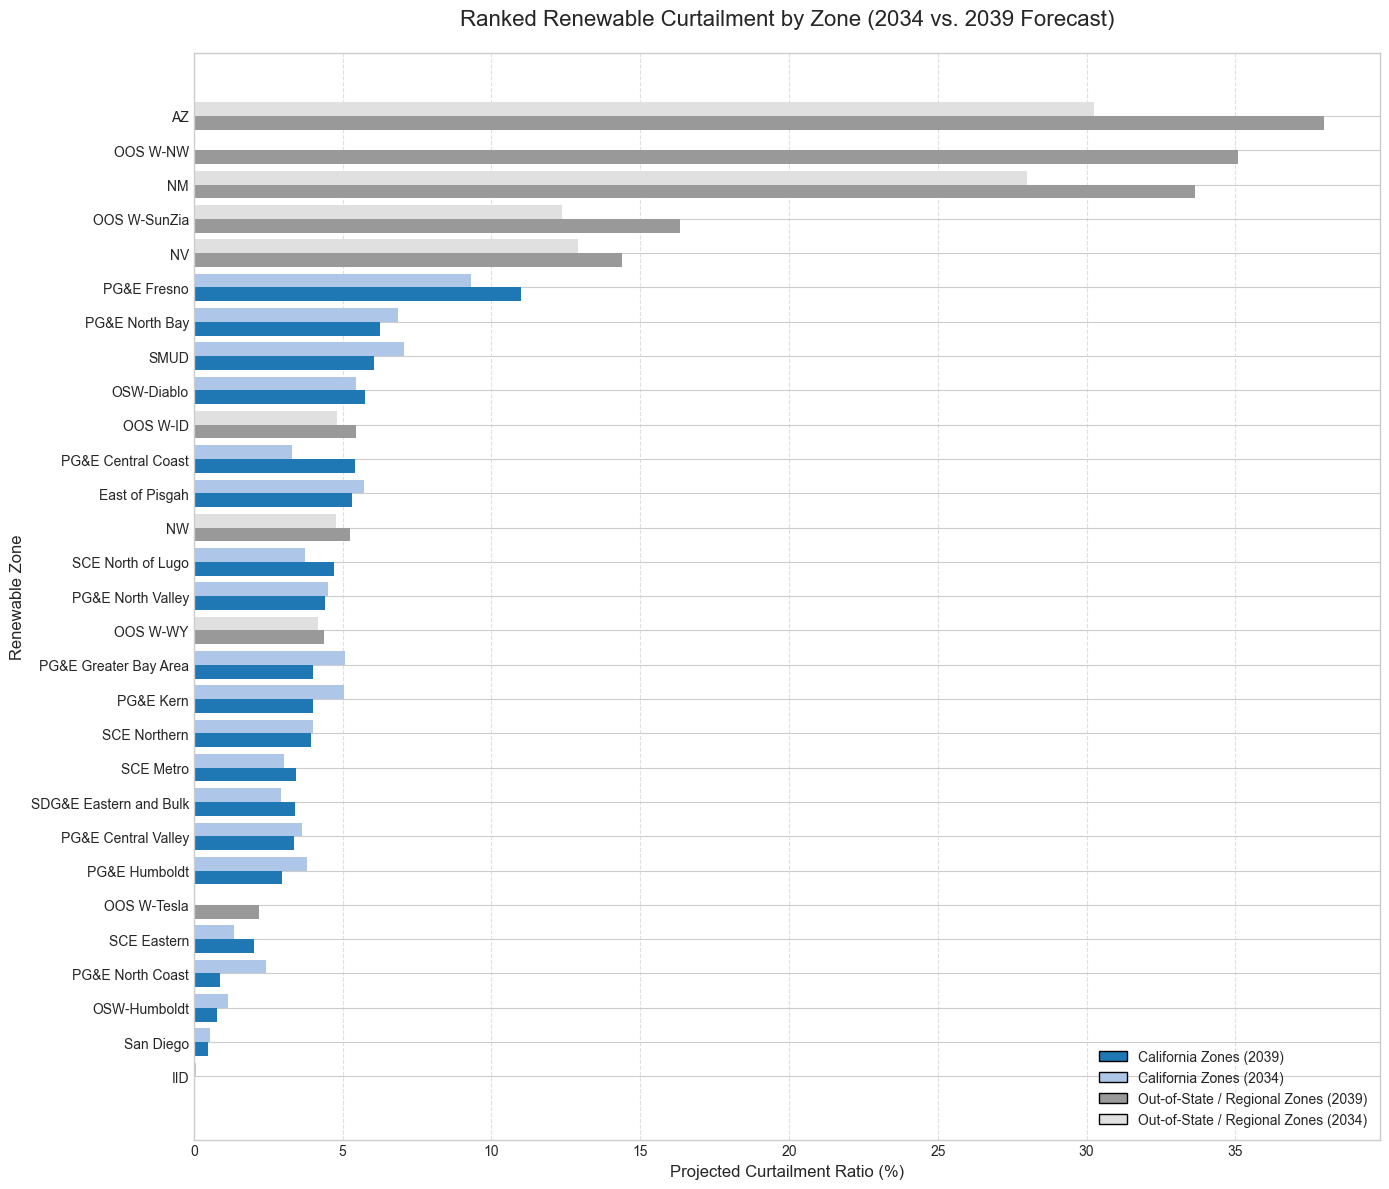

In [42]:
pcm_sorted = pcm_df.sort_values(by='Curtailment_Ratio_Pct_2039', ascending=True)

y_pos = np.arange(len(pcm_sorted))
height = 0.4

colors_2034 = ['#aec7e8' if state == 'CA' else '#e0e0e0' for state in pcm_sorted['State']]
colors_2039 = ['#1f77b4' if state == 'CA' else '#999999' for state in pcm_sorted['State']]

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 12))

ax.barh(y_pos + height / 2, pcm_sorted['Curtailment_Ratio_Pct_2034'], height, label='2034', color=colors_2034)
ax.barh(y_pos - height / 2, pcm_sorted['Curtailment_Ratio_Pct_2039'], height, label='2039', color=colors_2039)

ax.set_yticks(y_pos)
ax.set_yticklabels(pcm_sorted['Renewable_Zone'])

ax.set_xlabel('Projected Curtailment Ratio (%)', fontsize=12)
ax.set_ylabel('Renewable Zone', fontsize=12)
ax.set_title('Ranked Renewable Curtailment by Zone (2034 vs. 2039 Forecast)', fontsize=16, pad=20)

legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='California Zones (2039)'),
    Patch(facecolor='#aec7e8', edgecolor='black', label='California Zones (2034)'),
    Patch(facecolor='#999999', edgecolor='black', label='Out-of-State / Regional Zones (2039)'),
    Patch(facecolor='#e0e0e0', edgecolor='black', label='Out-of-State / Regional Zones (2034)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.tight_layout()
plt.show()

In [31]:
congestion_df = pd.read_csv(data_dir / 'congestion_costs.csv')

In [33]:
congestion_df.head()

,constrained_area,2034_cost_mill,2034_duration_hours,2039_cost_mill,2039_duration_hours
0,Path 15 Corridor,389.42,5468,521.80,7343
1,Path 26 Corridor,241.10,4503,206.28,4197
2,East of Pisgah,35.61,1378,86.87,3334
3,SWIP North,51.29,716,51.61,748
4,SCE Northern,19.69,1743,78.62,3348


In [34]:
congestion_df = congestion_df.sort_values(by='2034_cost_mill', ascending=False)

/var/folders/1s/l7126wmd6674c5hlyz6rwhpc0000gp/T/ipykernel_33882/3675783761.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2034_cost_mill', y='constrained_area', data=congestion_df, palette='viridis', ax=ax)


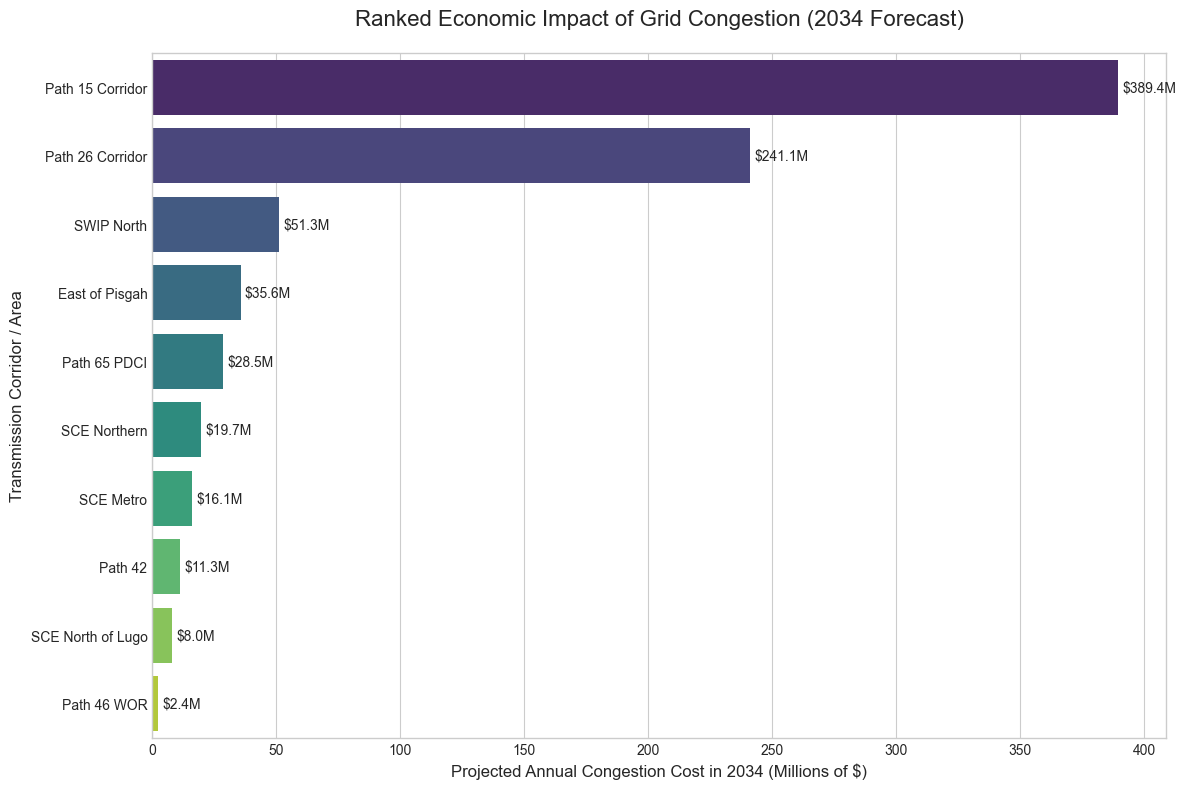

In [37]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(x='2034_cost_mill', y='constrained_area', data=congestion_df, palette='viridis', ax=ax)

ax.set_xlabel('Projected Annual Congestion Cost in 2034 (Millions of $)', fontsize=12)
ax.set_ylabel('Transmission Corridor / Area', fontsize=12)
ax.set_title('Ranked Economic Impact of Grid Congestion (2034 Forecast)', fontsize=16, pad=20)

for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fM', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

In [38]:
mix_df = pd.read_csv(data_dir / 'local_generation_mix_fresno.csv')

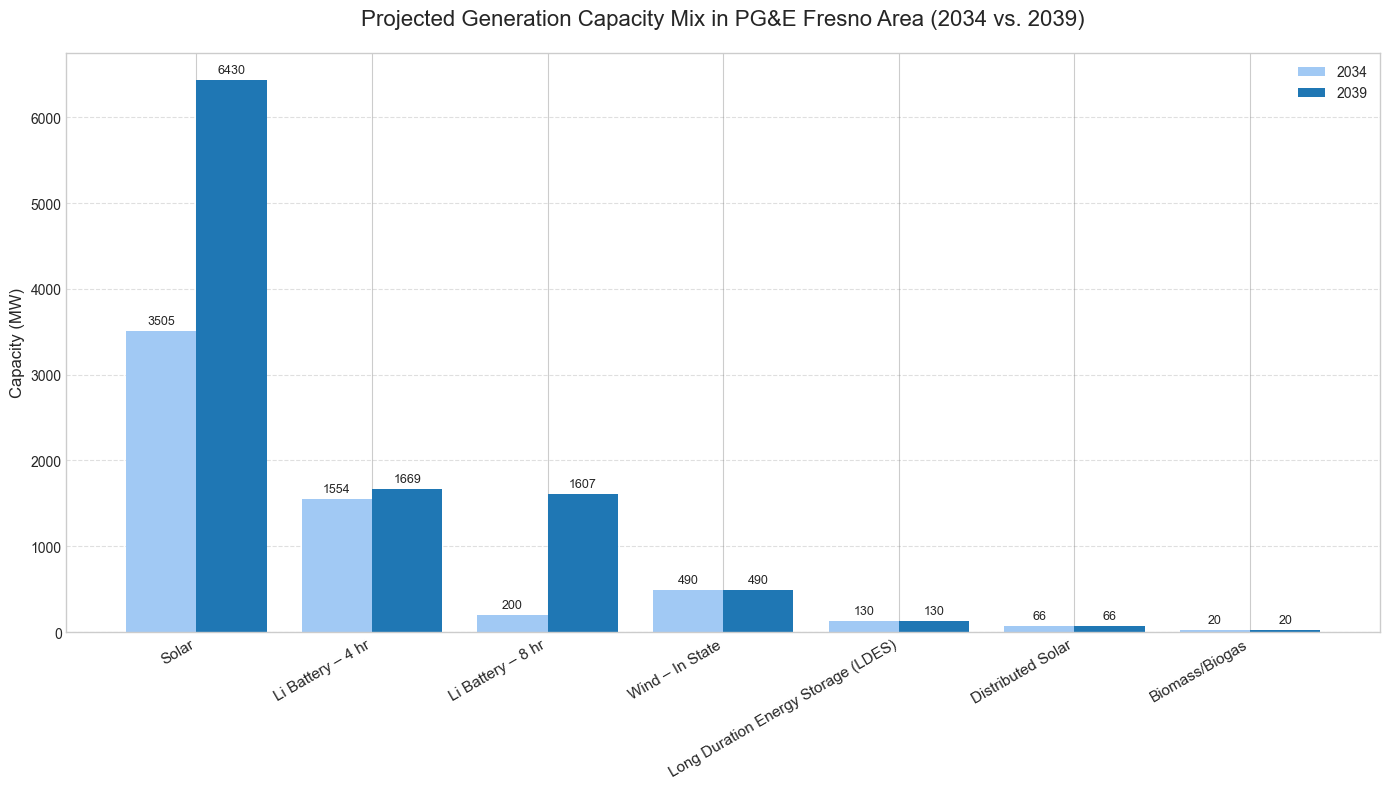

In [41]:
# Sort by 2039 capacity for a cleaner chart
df_mix_sorted = mix_df.sort_values(by='2039_capacity_MW', ascending=False)

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(14, 8))

x_indexes = np.arange(len(df_mix_sorted))
width = 0.4

rects1 = ax.bar(x_indexes - width/2, df_mix_sorted['2034_capacity_MW'], width, label='2034', color='#a1c9f4')
rects2 = ax.bar(x_indexes + width/2, df_mix_sorted['2039_capacity_MW'], width, label='2039', color='#1f77b4')

ax.set_ylabel('Capacity (MW)', fontsize=12)
ax.set_title('Projected Generation Capacity Mix in PG&E Fresno Area (2034 vs. 2039)', fontsize=16, pad=20)
ax.set_xticks(x_indexes)
ax.set_xticklabels(df_mix_sorted['resource_type'], rotation=30, ha='right', fontsize=11)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%d', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%d', fontsize=9)

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

fig.tight_layout()
plt.show()
